# Mastering TensorFlow: Day 16 - Building a Linear Regression Model


## Introduction to Linear Regression

Linear regression is a supervised learning algorithm used to predict a continuous output variable based on one or more input variables. The goal is to find the best-fitting straight line through the data points.

The equation of a simple linear regression model is:

\[ y = wx + b \]

where:
- \( y \) is the predicted output,
- \( x \) is the input feature,
- \( w \) is the weight (slope),
- \( b \) is the bias (intercept).

In this notebook, we'll implement linear regression using TensorFlow and learn how to train the model to find the optimal values of \( w \) and \( b \).


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


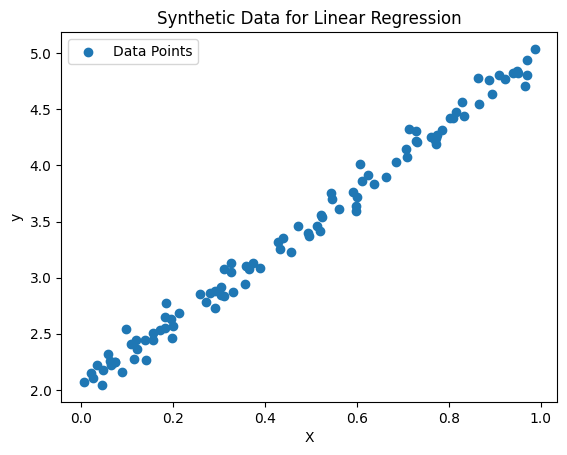

In [ ]:
# Generate synthetic data for training
np.random.seed(42)  # For reproducibility

# Parameters
true_w = 3.0
true_b = 2.0
num_samples = 100

# Generate inputs and noisy outputs
X = np.random.rand(num_samples).astype(np.float32)
noise = np.random.normal(0, 0.1, size=num_samples)
y = true_w * X + true_b + noise

# Plot the data
plt.scatter(X, y, label='Data Points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Data for Linear Regression')
plt.legend()
plt.show()


Explanation:

We create a synthetic dataset where the relationship between X and y follows a linear pattern with some added noise.

In [ ]:
# Create TensorFlow Dataset
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(buffer_size=100).batch(10)


Explanation:

We convert the NumPy arrays into a TensorFlow Dataset object, shuffle it for better training, and batch it.

In [ ]:
# Define the model
class LinearRegressionModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.w = tf.Variable(tf.random.normal([1]), name='weight')
        self.b = tf.Variable(tf.random.normal([1]), name='bias')

    def call(self, x):
        return self.w * x + self.b

model = LinearRegressionModel()


Explanation:

We create a custom model by subclassing tf.keras.Model, defining the weight and bias as variables.

In [ ]:
# Define loss function (Mean Squared Error) with type casting
def loss_fn(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  # Ensure y_true is float32
    y_pred = tf.cast(y_pred, tf.float32)  # Ensure y_pred is float32
    return tf.reduce_mean(tf.square(y_true - y_pred))


Explanation:

We use Mean Squared Error (MSE) as the loss function and Stochastic Gradient Descent (SGD) as the optimizer.

In [ ]:
# Training Loop
num_epochs = 20

for epoch in range(num_epochs):
    for batch_X, batch_y in dataset:
        with tf.GradientTape() as tape:
            predictions = model(batch_X)
            loss = loss_fn(batch_y, predictions)  # This line should now work correctly
        gradients = tape.gradient(loss, [model.w, model.b])
        optimizer.apply_gradients(zip(gradients, [model.w, model.b]))
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.numpy():.4f}, w: {model.w.numpy()[0]:.4f}, b: {model.b.numpy()[0]:.4f}')


Epoch 5, Loss: 0.0042, w: 2.7312, b: 2.1325
Epoch 10, Loss: 0.0087, w: 2.8453, b: 2.0754
Epoch 15, Loss: 0.0090, w: 2.9005, b: 2.0477
Epoch 20, Loss: 0.0092, w: 2.9237, b: 2.0275



Mean Squared Error on Training Data: 0.0082


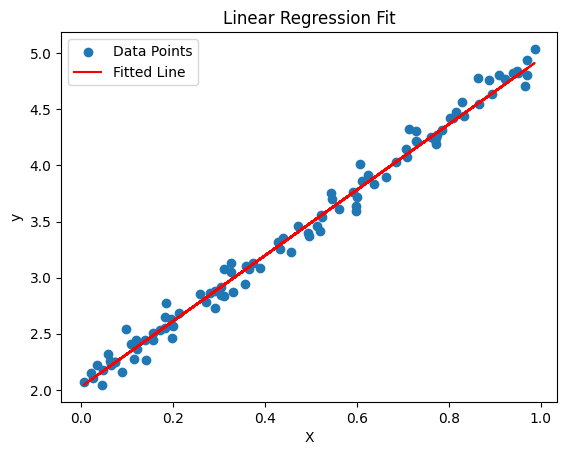

In [ ]:
# Make predictions on the training data
predictions = model(X)

# Calculate Mean Squared Error
mse = loss_fn(y, predictions).numpy()
print(f'\nMean Squared Error on Training Data: {mse:.4f}')

# Plot the results
plt.scatter(X, y, label='Data Points')
plt.plot(X, predictions, color='red', label='Fitted Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()


In [ ]:
# Predict new values
X_new = np.array([0.1, 0.5, 0.9], dtype=np.float32)
y_pred_new = model(X_new)

for x_val, y_pred_val in zip(X_new, y_pred_new.numpy()):
    print(f'For x = {x_val:.1f}, predicted y = {y_pred_val:.4f}')


For x = 0.1, predicted y = 2.3199
For x = 0.5, predicted y = 3.4894
For x = 0.9, predicted y = 4.6589


## Conclusion

We successfully built and trained a linear regression model using TensorFlow. By minimizing the loss function, we found the optimal values of the weight and bias that best fit our data. This basic example lays the groundwork for more complex models and algorithms in machine learning.

In this notebook, we covered:
- Generating synthetic data for regression.
- Building a custom model in TensorFlow.
- Implementing a training loop with gradient descent.
- Evaluating the model's performance.
- Making predictions with the trained model.

Stay tuned for the next session, where we'll delve deeper into machine learning algorithms using TensorFlow!
